# Can the next pitch type thrown by a Blue Jays pitcher be predicted using pitch context and game state?

We want to build a multiclass model to predict pitch type from information available *before* each pitch: the count, baserunners, batter/pitcher handedness, pitcher identity, pitch number within the at-bat, cumulative pitch count in the game, and the previous pitch in the at-bat. The analysis uses a chronologically sorted Blue Jays pitch table loaded from `analysis.ipynb`


In [ ]:
# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Data and numerics
import pandas                  as pd
import numpy                   as np

# Plotting
import matplotlib.pyplot       as plt
import seaborn                 as sns

# Modeling and metrics
from sklearn import metrics
from sklearn import dummy
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Display plots inline in the notebook
%matplotlib inline

plt.style.use('ggplot')


## Features

Game state

- `inning`, `outs_when_up`
- `balls`, `strikes`, and combined `count_state` (e.g. `1-2`)
- `score_diff` = `fld_score` - `bat_score`
- `on_1b_flag`, `on_2b_flag`, `on_3b_flag` (runner on base or not)

Pitch context

- `prev_pitch_name` — previous pitch in the same at-bat (lagged within game/at-bat order)
- `pitch_number_in_ab` — index of the pitch inside the at-bat
- `cumulative_pitch_count` — pitcher's pitch count within that game

Matchup

- `stand` (batter L/R), `p_throws` (pitcher L/R)
- `player_name` — pitcher identity (high cardinality; encoded as dummy variables)


### Data preparation

The table is sorted by `game_pk`, `at_bat_number`, and `pitch_number` so that the lag feature respect pitch order within each game. Within each at-bat, `prev_pitch_name` is the prior row's `pitch_name`. `pitch_number_in_ab` is a cumulative index within the at-bat; `cumulative_pitch_count` counts pitches by pitcher within each game. Runner columns are converted to 0/1 flags, and `count_state` combines balls and strikes for plotting and modeling.


In [ ]:
# Import Blue Jays pitch table from another notebook's %store
%store -r bj_df

# Chronological order: game -> at-bat -> pitch 
sorted_bj = bj_df.sort_values(by=['game_pk', 'at_bat_number', 'pitch_number']).reset_index(drop=True)

# Pitch context within each ab (ab = at-bat)
ab_group = sorted_bj.groupby(['game_pk', 'at_bat_number'])
sorted_bj['prev_pitch_name']   = ab_group['pitch_name'].shift(1)  # prior pitch in this AB; NaN on first pitch
sorted_bj['pitch_number_in_ab'] = ab_group.cumcount()           # 0-based index of pitch within AB

# Pitcher's total pitches thrown so far in this game (fatigue / usage proxy)
sorted_bj['cumulative_pitch_count'] = sorted_bj.groupby(['game_pk', 'pitcher']).cumcount()

# Game state
sorted_bj['score_diff'] = sorted_bj['fld_score'] - sorted_bj['bat_score']

# Baserunners: NaN -> empty base, any ID -> runner present
sorted_bj['on_1b_flag'] = sorted_bj['on_1b'].notna().astype(int)
sorted_bj['on_2b_flag'] = sorted_bj['on_2b'].notna().astype(int)
sorted_bj['on_3b_flag'] = sorted_bj['on_3b'].notna().astype(int)

# Single categorical label for balls-strikes
sorted_bj['count_state'] = sorted_bj['balls'].astype(str) + '-' + sorted_bj['strikes'].astype(str)

sorted_bj[['player_name', 'pitch_name', 'prev_pitch_name',
           'pitch_number_in_ab', 'cumulative_pitch_count', 'score_diff',
           'on_1b_flag', 'on_2b_flag', 'on_3b_flag', 'count_state',
           'balls', 'strikes', 'inning', 'outs_when_up', 'stand', 'p_throws']].head(10)


,player_name,pitch_name,prev_pitch_name,pitch_number_in_ab,cumulative_pitch_count,score_diff,on_1b_flag,on_2b_flag,on_3b_flag,count_state,balls,strikes,inning,outs_when_up,stand,p_throws
0,"Yesavage, Trey",4-Seam Fastball,NaN,0,0,2,0,0,0,0-0,0,0,1,0,L,R
1,"Yesavage, Trey",Split-Finger,4-Seam Fastball,1,1,2,0,0,0,1-0,1,0,1,0,L,R
2,"Yesavage, Trey",Slider,Split-Finger,2,2,2,0,0,0,1-1,1,1,1,0,L,R
3,"Yesavage, Trey",Split-Finger,Slider,3,3,2,0,0,0,1-2,1,2,1,0,L,R
4,"Yesavage, Trey",Slider,Split-Finger,4,4,2,0,0,0,2-2,2,2,1,0,L,R
5,"Yesavage, Trey",4-Seam Fastball,Slider,5,5,2,0,0,0,2-2,2,2,1,0,L,R
6,"Yesavage, Trey",4-Seam Fastball,NaN,0,6,2,0,0,0,0-0,0,0,1,1,R,R
7,"Yesavage, Trey",4-Seam Fastball,4-Seam Fastball,1,7,2,0,0,0,0-1,0,1,1,1,R,R
8,"Yesavage, Trey",4-Seam Fastball,NaN,0,8,2,0,0,0,0-0,0,0,1,2,R,R
9,"Yesavage, Trey",Slider,4-Seam Fastball,1,9,2,0,0,0,0-1,0,1,1,2,R,R


## Exploratory Data Analysis

Before building the model, we inspect how pitches behave marginally and conditionally. This answers two questions: (1) whether the target classes are balanced (which sets expectations for accuracy and the naive baseline), and (2) whether pitch type depends on observable context, especially the count and the previous pitch, so that those features are worth including later.
In order, we:
1. Plot the overall pitch-type distribution (counts and shares) to see class imbalance.
2. Build a count × pitch type heatmap: within each balls–strikes state, what fraction of pitches is each type? That shows whether mix changes with the count.
3. Build a transition matrix P(next pitch | previous pitch) on pitches after the first in an at-bat, to see if sequencing departs from a single global mix.
4. Run a chi-square test of independence on pitch type vs. count to complement the heatmap with a formal test of association.


### Pitch type distribution

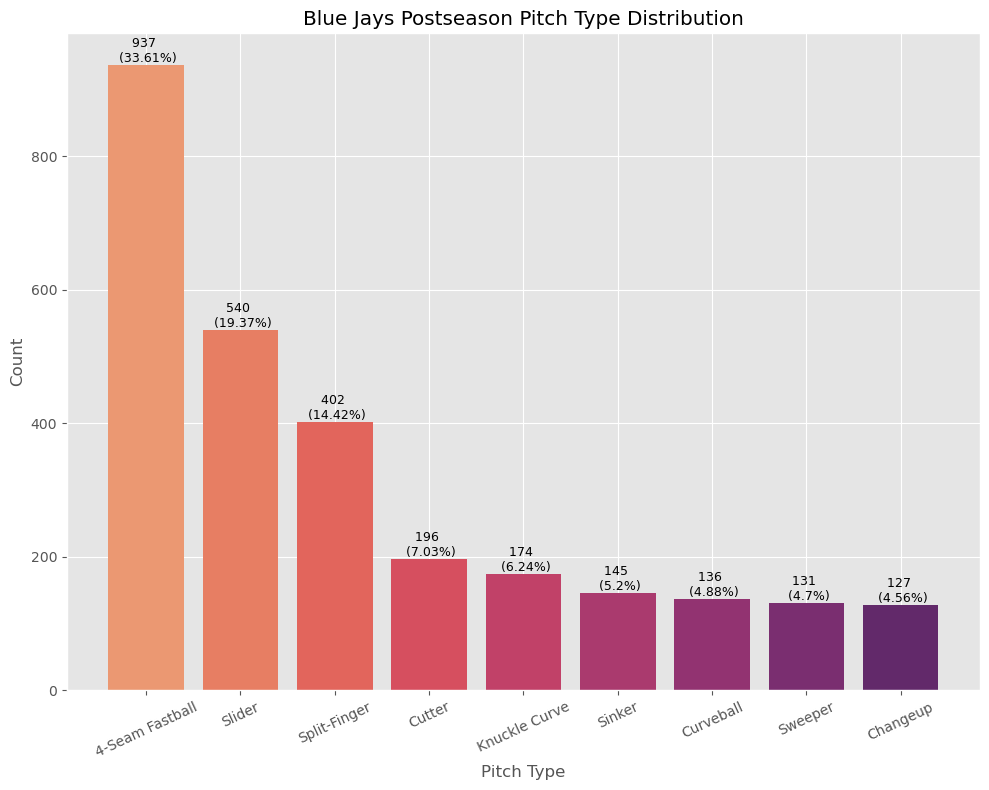

In [ ]:
# Bar chart: how often each pitch type appears (class imbalance check)
pitch_counts = sorted_bj['pitch_name'].value_counts()
total = len(sorted_bj)

plt.figure(figsize=(10, 8))
bars = plt.bar(pitch_counts.index, pitch_counts.values, color=sns.color_palette('flare', len(pitch_counts)))

# Annotate bars with raw count and share of all pitches
for bar, count in zip(bars, pitch_counts.values):
    percent = count / total * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{count} \n ({round(percent,2)}%)', ha='center', va='bottom', fontsize=9)

plt.xlabel('Pitch Type')
plt.ylabel('Count')
plt.title('Blue Jays Postseason Pitch Type Distribution')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


**Result** 

The bar chart shows a strongly skewed mix. 4-Seam Fastball has the largest share of pitches, with remaining pitch types forming a long tail. That skew sets a naive baseline: a model that always predicts "4-Seam Fastball" would achieve accuracy equal to the fastball's usage rate. Our model must significantly exceed this threshold to demonstrate that pitch selection is predictable from context.


### Pitch usage by count heatmap


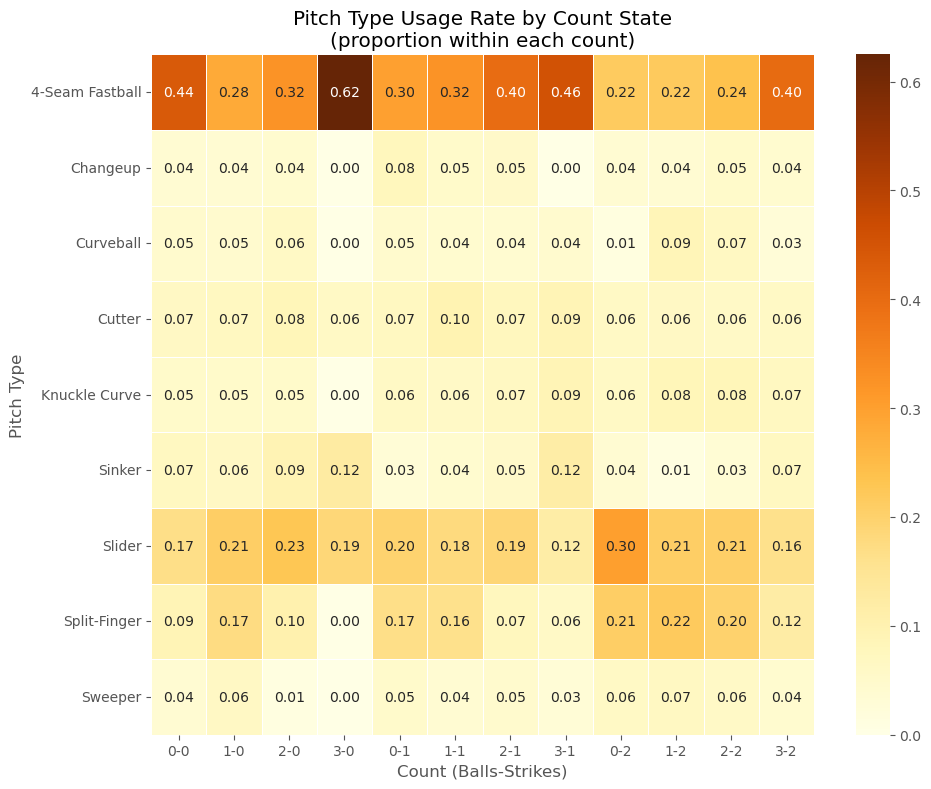

In [ ]:
# Standard MLB count order for consistent heatmap columns
count_order = ['0-0','1-0','2-0','3-0',
               '0-1','1-1','2-1','3-1',
               '0-2','1-2','2-2','3-2']

crosstab = pd.crosstab(sorted_bj['pitch_name'], sorted_bj['count_state'], normalize='columns')
crosstab = crosstab[count_order]

plt.figure(figsize=(10, 8))
sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='YlOrBr', linewidths=0.5)
plt.title('Pitch Type Usage Rate by Count State\n(proportion within each count)')
plt.xlabel('Count (Balls-Strikes)')
plt.ylabel('Pitch Type')
plt.tight_layout()
plt.show()


**Result**

The heatmap reveals clear count-dependent pitch selection patterns. On hitter-favored counts (3-0, 3-1, 2-0), fastball usage spikes, meaning pitchers need to throw strikes and default to their most reliable pitch. On pitcher-favored counts (0-2, 1-2), off-speed and breaking ball usage increases as pitchers try to get batters to chase pitches outside the zone. The fact that pitch mix shifts meaningfully across count states is strong visual evidence that the count is a useful predictor for our model. We can say that the pitch selection is influenced by the game situation.


### Pitch-to-pitch transition matrix


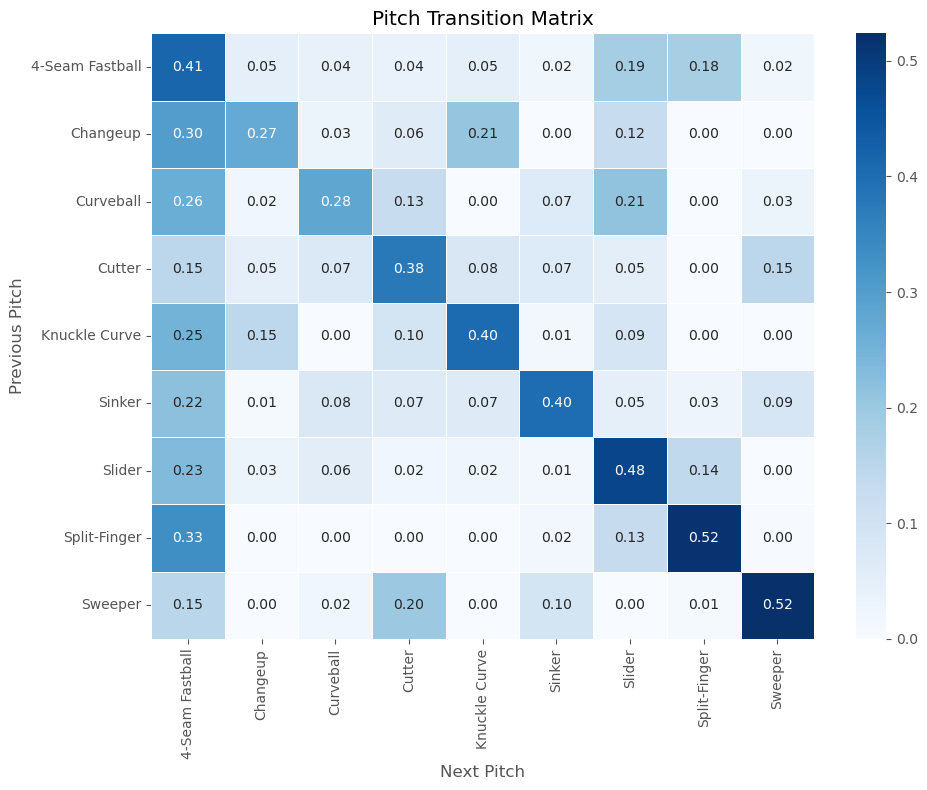

In [ ]:
# Exclude first pitch of each AB (no previous pitch to condition on)
seq_df = sorted_bj.dropna(subset=['prev_pitch_name'])

# P(next pitch | previous pitch): rows sum to 1 — sequencing pattern
transition = pd.crosstab(seq_df['prev_pitch_name'], seq_df['pitch_name'], normalize='index')

plt.figure(figsize=(10, 8))
sns.heatmap(transition, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Pitch Transition Matrix')
plt.xlabel('Next Pitch')
plt.ylabel('Previous Pitch')
plt.tight_layout()
plt.show()


**Result** 

Row profiles differ across previous-pitch types: the distribution of the next pitch is not the same after a 4-Seam Fastball as after a slider, curve, or splitter. Several transitions show elevated probability mass moving from hard pitches into breaking or off-speed offerings, consistent with setup and finish sequencing within at-bats. Overall, sequencing departs from a single global pitch mix, so the previous pitch carries predictive information beyond marginal frequencies.


### Chi-square test: pitch type vs. count

In [ ]:
# Contingency table: pitch type × count (raw counts)
contingency = pd.crosstab(sorted_bj['pitch_name'], columns=sorted_bj['count_state'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"p-value: {p_value}")

if p_value < 0.05:
    print("Result: Reject the null hypothesis at p = 0.05. Pitch selection is NOT independent of the count state.")
else:
    print("Result: Fail to reject the null hypothesis. No significant dependence found.")


p-value: 3.405858529772178e-14
Result: Reject the null hypothesis at p = 0.05. Pitch selection is NOT independent of the count state.


**Result** 

The chi-square statistic corresponds to p-value far below 0.05 so we reject independence between pitch type and count. Pitch mix and count state are strongly associated here, consistent with the count heatmap.

### Feature encoding and train/test split

Categorical columns (`prev_pitch_name`, `count_state`, `stand`, `p_throws`, `player_name`) are one-hot encoded. Missing `prev_pitch_name` on the first pitch of an at-bat is filled with `None` so every row has a category. Numeric columns are concatenated without scaling for the random forest.

Games are ordered chronologically by `game_pk`; the first 80% of games are training and the last 20% are test.


In [ ]:
# Missing previous pitch only on first pitch of AB — use explicit category for one-hot
sorted_bj['prev_pitch_name'] = sorted_bj['prev_pitch_name'].fillna('none')

categorical_features = ['prev_pitch_name', 'count_state', 'stand', 'p_throws', 'player_name']
numeric_features     = ['pitch_number_in_ab', 'cumulative_pitch_count', 'score_diff',
                        'on_1b_flag', 'on_2b_flag', 'on_3b_flag', 'inning', 'outs_when_up']

y = sorted_bj['pitch_name']  # multiclass target

# Dummy variables for categorical
X_cat = pd.get_dummies(sorted_bj[categorical_features], drop_first=False, dtype=int)
X_num = sorted_bj[numeric_features].copy()
X = pd.concat([X_num, X_cat], axis=1)

# Temporal split by game: early games train, later games test
unique_games = sorted_bj['game_pk'].unique()
split_index = int(len(unique_games) * 0.80)
train_games = set(unique_games[:split_index])

train_mask = sorted_bj['game_pk'].isin(train_games)
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Training set: {len(X_train)}")
print(f"Test set: {len(X_test)}")
print(f"Feature columns: {X.shape[1]}")


Training set: 2191
Test set: 597
Feature columns: 49


In [ ]:
# Count dummy columns created per categorical source field
print("One-hot encoded categorical features:")
for feat in categorical_features:
    cols = [c for c in X_cat.columns if c.startswith(feat + '_')]
    print(f"{feat}: {len(cols)} columns")

X.head()


One-hot encoded categorical features:
prev_pitch_name: 10 columns
count_state: 12 columns
stand: 2 columns
p_throws: 2 columns
player_name: 15 columns


,pitch_number_in_ab,cumulative_pitch_count,score_diff,on_1b_flag,on_2b_flag,on_3b_flag,inning,outs_when_up,prev_pitch_name_4-Seam Fastball,prev_pitch_name_Changeup,...,"player_name_Fluharty, Mason","player_name_Gausman, Kevin","player_name_Hoffman, Jeff","player_name_Lauer, Eric","player_name_Little, Brendon","player_name_Nance, Tommy","player_name_Rodríguez, Yariel","player_name_Scherzer, Max","player_name_Varland, Louis","player_name_Yesavage, Trey"
0,0,0,2,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,1,2,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
2,2,2,2,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,3,3,2,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,4,4,2,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## Modeling

1. `Naive Baseline` — Always predict the majority class in the training set. This mirrors "guess the fastball every time" and matches the imbalance discussion above.
2. `Random Forest Classifier` — If it beats the baseline, nonlinear and interaction effects (e.g. count × pitcher) may matter; trees can capture those without explicit cross terms.

We tune `max_depth` with `5-fold stratified cross-validation` on the training set and report `accuracy` on the held-out test games.


### Naive Baseline (most frequent class)

This classifier establishes the accuracy floor. If the random forest cannot beat it, then under this metric, observable context does not improve on always picking the most common pitch.


In [ ]:
# Baseline: always predict training-set majority class (replicates the "guess the fastball" logic)
dum = dummy.DummyClassifier(strategy='most_frequent')
dum.fit(X_train, y_train)
y_pred_dummy = dum.predict(X_test)

naive_acc = metrics.accuracy_score(y_test, y_pred_dummy)

most_common = y_train.value_counts().idxmax()
print(f"Naive Baseline: always predict '{most_common}'")
print(f"Accuracy: {round(naive_acc * 100, 2)}%")


Naive Baseline: always predict '4-Seam Fastball'
Accuracy: 30.32%


## Random Forest Classifier

1. 5-fold stratified cross-validation on the training set to compare `max_depth` values.
2. Refit on the full training set with the chosen depth and evaluate on held-out test games.
3. Confusion matrix (test) and one-vs-rest ROC curves summarize misclassification patterns and class-wise probability separation.


### 5-Fold Stratified Cross-Validation

We use cross validation with 5 folds to evaluate Random Forest models at different tree depths (3, 5, 8, 12). We fix `n_estimators=100` and `random_state=0` for reproducibility. For each depth, we record the mean and standard deviation of accuracy across folds to objectively select the best hyperparameter.

In [ ]:
# Tune max_depth with 5-fold CV on X_train only; pick depth with best mean val accuracy
# Stratified folds keep class proportions similar across train/val splits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

depth_candidates = [3, 5, 8, 12]
cv_results = {}

for depth in depth_candidates:
    fold_accs = []
    for train_index, val_index in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

        clf = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=0)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val)
        fold_accs.append(accuracy_score(y_val, y_pred))

    mean_acc = np.mean(fold_accs)
    std_acc  = np.std(fold_accs)
    cv_results[depth] = (mean_acc, std_acc, fold_accs)

best_depth = max(cv_results, key=lambda d: cv_results[d][0])
print(f"\nBest max_depth = {best_depth}\nCV Accuracy = {cv_results[best_depth][0]:.4f} ± {cv_results[best_depth][1]:.4f}")



Best max_depth = 8
CV Accuracy = 0.4774 ± 0.0215


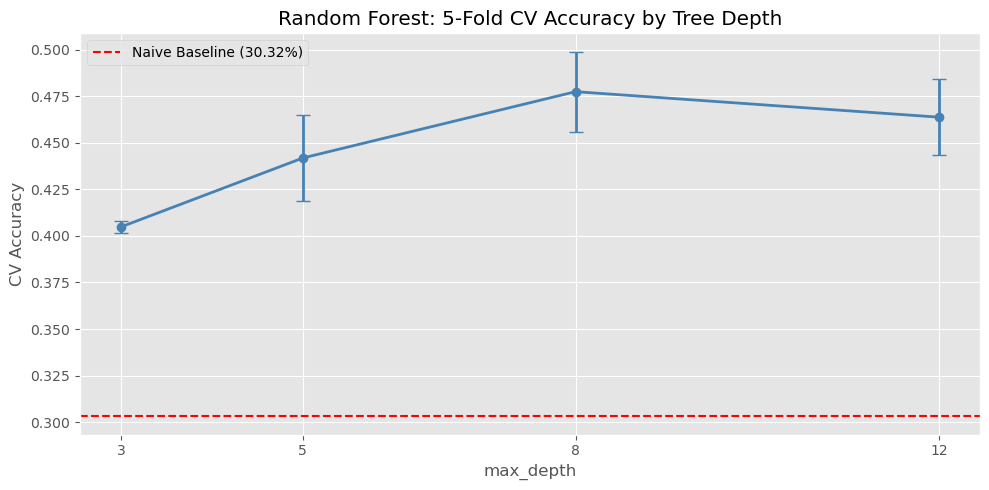

In [ ]:
# Cross-validation accuracy vs tree depth. Compare to naive baseline horizontal line
depths = list(cv_results.keys())
means  = [cv_results[d][0] for d in depths]
stds   = [cv_results[d][1] for d in depths]

plt.figure(figsize=(10, 5))
plt.errorbar(depths, means, yerr=stds, fmt='-o', capsize=5, color='steelblue', linewidth=2)
plt.axhline(y=naive_acc, color='red', linestyle='--', linewidth=1.5, label=f'Naive Baseline ({naive_acc:.2%})')
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.title('Random Forest: 5-Fold CV Accuracy by Tree Depth')
plt.xticks(depths)
plt.legend()
plt.tight_layout()
plt.show()


**Result**

Mean CV accuracy exceeds naive baseline accuracy for every `max_depth` in the grid (3, 5, 8, 12), so the forest is using the features rather than collapsing to the majority class. Error bars show fold-to-fold spread. Deeper trees are not uniformly better, mean accuracy plateaus or falls at larger depths in this plot.


### Final fit and test accuracy

We refit the random forest on all training rows with `max_depth = best_depth` from cross-validation, then measure accuracy on test rows from held-out games. Test accuracy is the headline number for comparing to the baseline.


In [ ]:
# Fit on full training data with depth chosen by cross-validation. Evaluate on held-out games only
rf_final = RandomForestClassifier(n_estimators=100, max_depth=best_depth, random_state=0)
rf_final.fit(X_train, y_train)

y_pred_rf = rf_final.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest (max_depth={best_depth})")
print(f"Test Accuracy:  {round(rf_acc,3) * 100}%")
print(f"Naive Baseline: {round(naive_acc,3) * 100}%")


Random Forest (max_depth=8)
Test Accuracy:  44.2%
Naive Baseline: 30.3%


### Confusion matrix (test set)


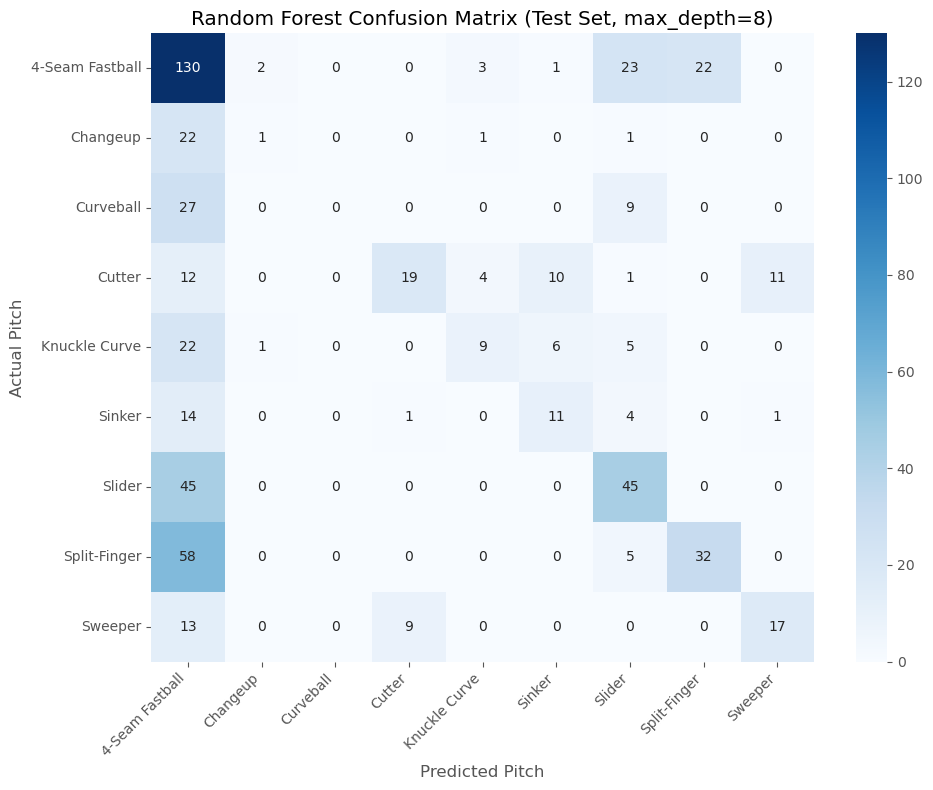

In [ ]:
# Rows = actual class, columns = predicted class
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_rf, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Pitch')
plt.ylabel('Actual Pitch')
plt.title(f'Random Forest Confusion Matrix (Test Set, max_depth={best_depth})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Result**

The largest counts fall on the diagonal for the most frequent pitch types, especially 4-Seam Fastball, so the model tracks the dominant classes. The biggest off-diagonal errors tend to pair similar pitch families (e.g. fastball vs. sinker/cutter-type pitches). Low-frequency pitch types show more confusion with the majority class, consistent with class imbalance in training.


### ROC curves (one-vs-rest)


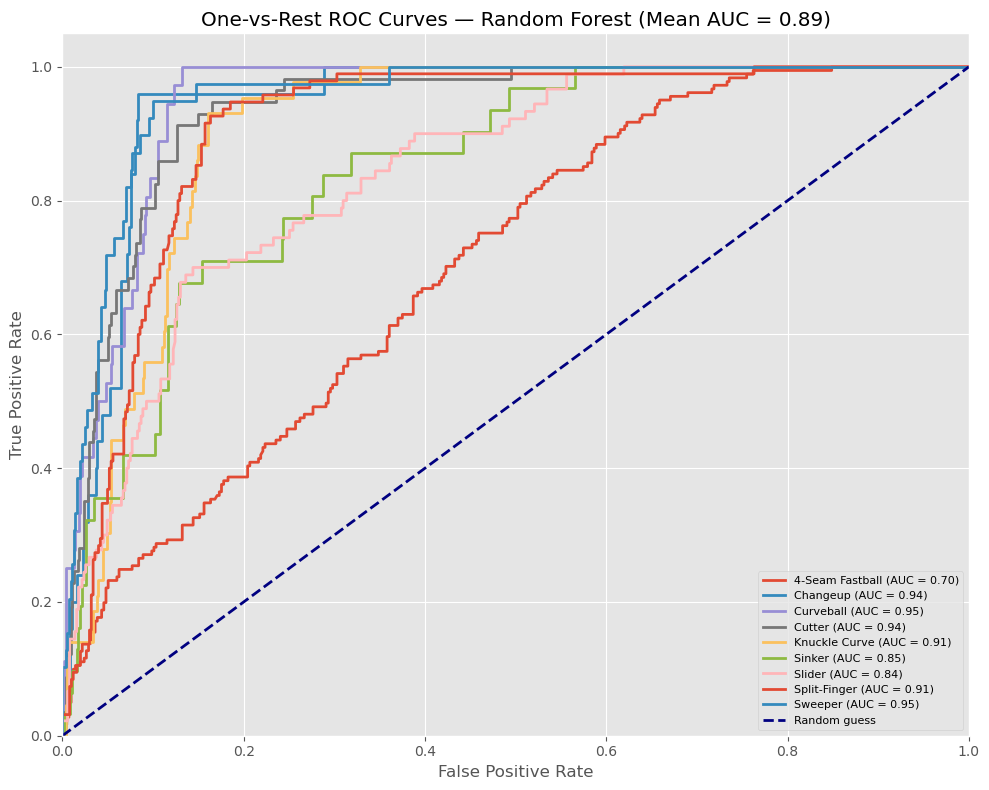

In [ ]:
# Multiclass ROC: one curve per pitch type (positive vs all others)
y_test_bin  = label_binarize(y_test, classes=labels)
y_prob_rf   = rf_final.predict_proba(X_test)

plt.figure(figsize=(10, 8))
line_width = 2
all_auc = {}

for i, label in enumerate(labels):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    auc_i = auc(fpr_i, tpr_i)
    all_auc[label] = auc_i
    plt.plot(fpr_i, tpr_i, lw=line_width, label=f"{label} (AUC = {auc_i:.2f})")

mean_auc = np.mean(list(all_auc.values()))
plt.plot([0, 1], [0, 1], color='navy', lw=line_width, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'One-vs-Rest ROC Curves — Random Forest (Mean AUC = {mean_auc:.2f})')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


**Result**

Per-class AUC in the legend ranges from stronger separation for high-volume pitch types to weaker separation for rarer classes; most curves sit above the reference diagonal, so predicted probabilities rank positives above random for most types. The title’s mean AUC summarizes overall one-vs-rest discriminability and complements accuracy under class imbalance.

## Conclusion

The Random Forest Classifier achieves higher test accuracy than the Naive Baseline, which supports the idea that pitch type is partially predictable from game state and sequencing features in this sample. That answers the research question: Context helps beyond always guessing the most common pitch.

However, results are specific to this Blue Jays pitch table and postseason context. Class imbalance still makes rare pitches hard to identify, accuracy alone does not capture cost asymmetry between pitch types. Future work could add calibration, cost-sensitive metrics, or pitcher-specific models.
